In [1]:
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
file = "StudentPerformanceFactors.csv"
path = os.getcwd() + '\\' + file
df = pd.read_csv(path)
print("Shape:", df.shape)

Shape: (6607, 20)


In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
#Columns
df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
#Statistical Summary
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
#Missing Values
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [8]:
#Duplicates
df.duplicated().sum()

0

In [9]:
#Filling missing values with Mode

df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0], inplace=True)
df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0], inplace=True)
df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0], inplace=True)

In [10]:
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


### Numerical Features Analysis

In [11]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

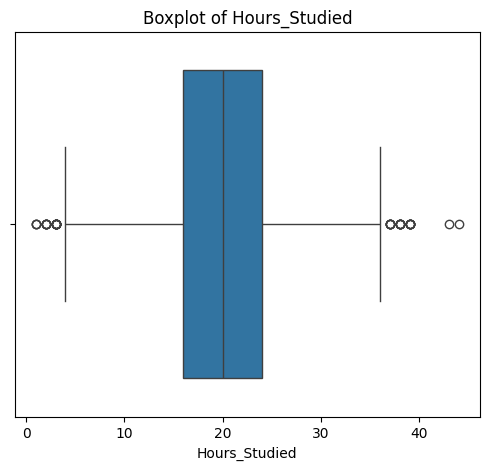

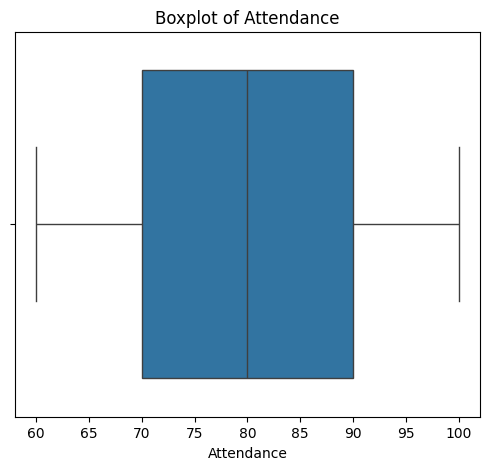

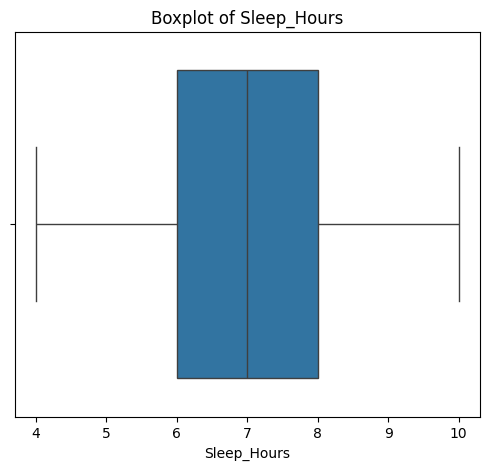

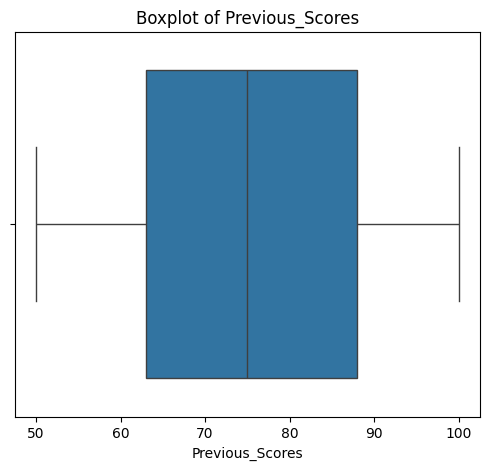

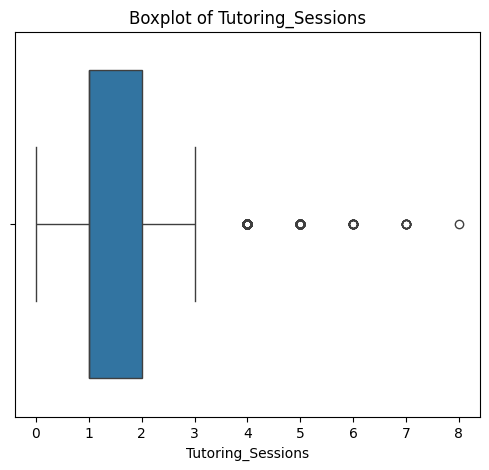

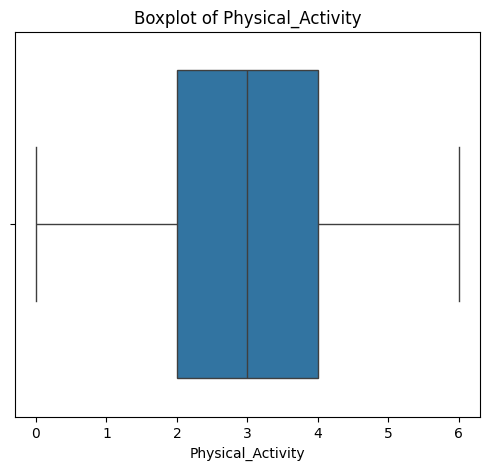

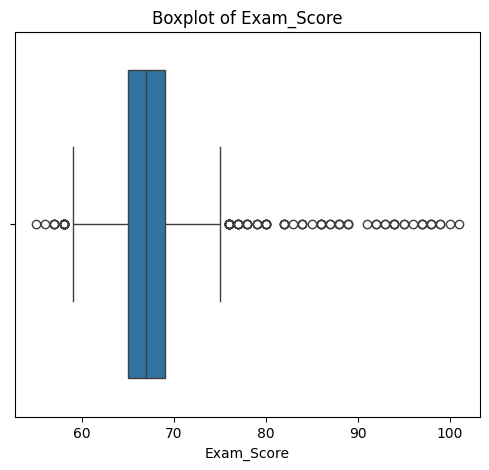

In [12]:
#Outlier detection
for col in numeric_df.columns:
    plt.figure(figsize=(6, 5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [13]:
df["Hours_Studied"].describe()

count    6607.000000
mean       19.975329
std         5.990594
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: Hours_Studied, dtype: float64

In [14]:
df["Tutoring_Sessions"].describe()

count    6607.000000
mean        1.493719
std         1.230570
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: Tutoring_Sessions, dtype: float64

In [15]:
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [16]:
df.loc[df["Exam_Score"] > 100, "Exam_Score"] = 100

In [17]:
df["Exam_Score"].max()

100

Outliers were observed in Hours_Studied, Tutoring_Sessions, and Exam_Score. As these values are realistic and within meaningful ranges, values are retained.

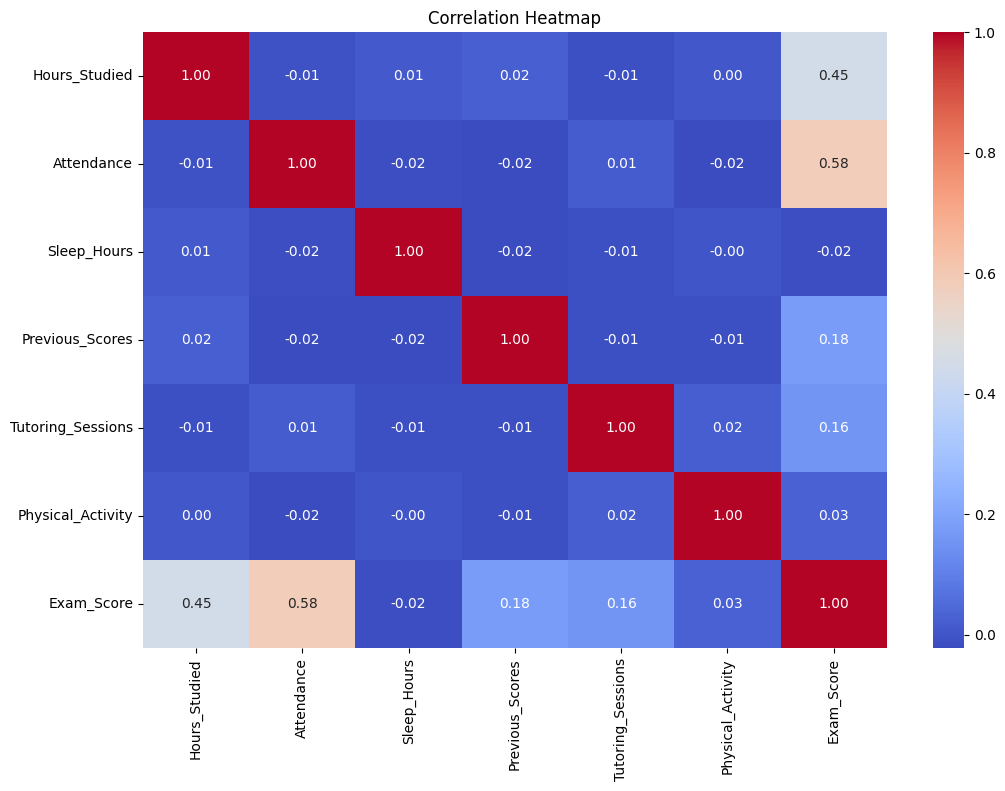

In [18]:
#Correlation heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

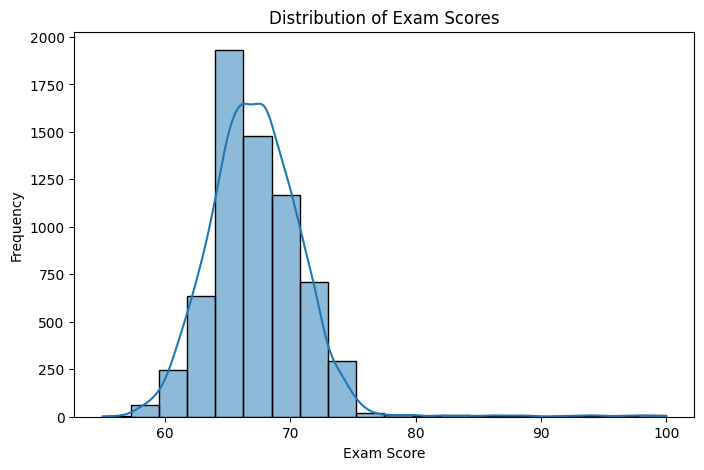

In [19]:
#Exam_Score distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()


 
Exam scores are concentrated within a relatively narrow range, with most students scoring between 60 and 70.

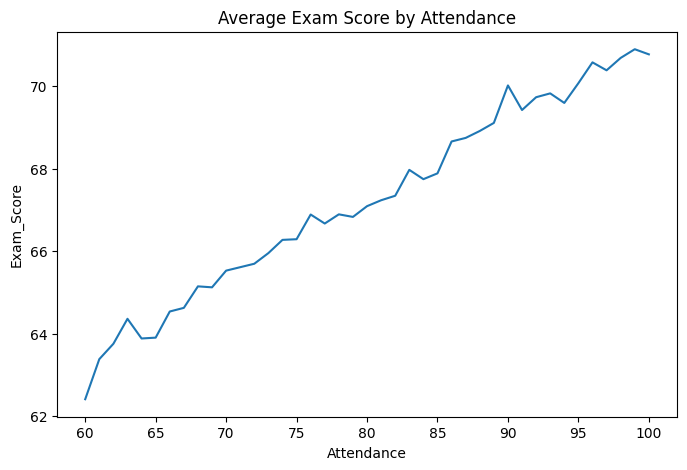

In [20]:
#Attendance vs Exam Score
attendance_mean = df.groupby("Attendance")["Exam_Score"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x="Attendance", y="Exam_Score", data=attendance_mean)

plt.title("Average Exam Score by Attendance")
plt.show()


Students with greater attendance generally exhibited higher average exam scores, indicating a positive relationship between attendance and academic performance. So students with better attendance tend to score higher.

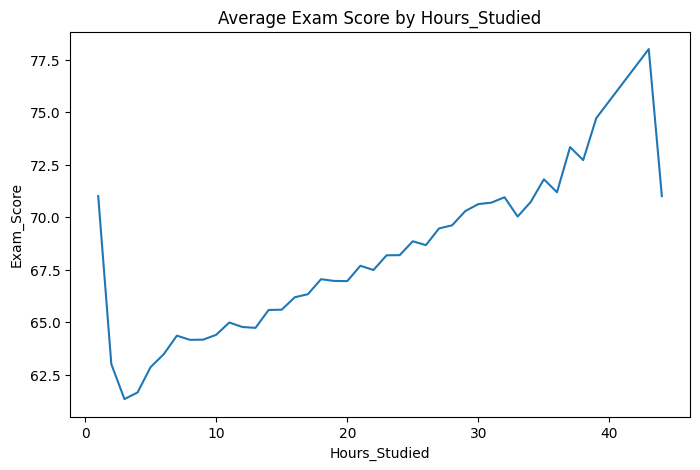

In [21]:
#Hours Studied vs Exam Score
hours_mean = df.groupby("Hours_Studied")["Exam_Score"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x="Hours_Studied", y="Exam_Score", data=hours_mean)

plt.title("Average Exam Score by Hours_Studied")
plt.show()

 Students with high study hours generally exhibited higher average exam scores, so this shows a positive relationship between study time and academic performance.

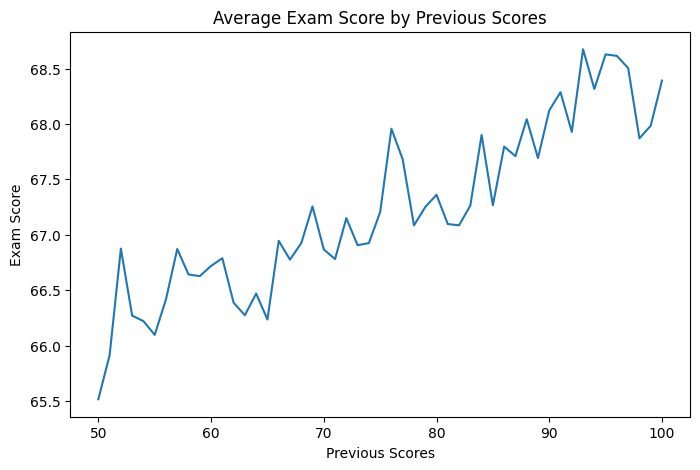

In [22]:
# Previous Scores vs Exam Score
previous_scores_mean = df.groupby("Previous_Scores")["Exam_Score"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x="Previous_Scores", y="Exam_Score", data=previous_scores_mean)

plt.title("Average Exam Score by Previous Scores")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.show()

 Previous academic performance shows a mild positive relationship with current exam scores. This suggests that past scores contributes to, but does not solely determine, future scores.

### Data Preprocessing

In [23]:
ordinal_cols = ["Parental_Involvement","Access_to_Resources","Motivation_Level","Family_Income","Teacher_Quality",
                "Peer_Influence","Distance_from_Home"]

for col in ordinal_cols:
    print(df[col].unique())

['Low' 'Medium' 'High']
['High' 'Medium' 'Low']
['Low' 'Medium' 'High']
['Low' 'Medium' 'High']
['Medium' 'High' 'Low']
['Positive' 'Negative' 'Neutral']
['Near' 'Moderate' 'Far']


In [24]:
ordinal_mappings = { "Parental_Involvement": {"Low": 0, "Medium": 1, "High": 2},
                    "Access_to_Resources": {"Low": 0, "Medium": 1, "High": 2},
                    "Motivation_Level": {"Low": 0, "Medium": 1, "High": 2},
                    "Family_Income": {"Low": 0, "Medium": 1, "High": 2},
                    "Teacher_Quality": {"Low": 0, "Medium": 1, "High": 2},
                    "Peer_Influence": {"Negative": 0, "Neutral": 1, "Positive": 2},
                    "Distance_from_Home": {"Near": 0, "Moderate": 1, "Far": 2}
                   }

In [25]:
for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)
    
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,No,7,73,0,Yes,0,0,1,Public,2,3,No,High School,0,Male,67
1,19,64,0,1,No,8,59,0,Yes,2,1,1,Public,0,4,No,College,1,Female,61
2,24,98,1,1,Yes,7,91,1,Yes,2,1,1,Public,1,4,No,Postgraduate,0,Male,74
3,29,89,0,1,Yes,8,98,1,Yes,1,1,1,Public,0,4,No,High School,1,Male,71
4,19,92,1,1,Yes,6,65,1,Yes,3,1,2,Public,1,4,No,College,0,Female,70


In [26]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Extracurricular_Activities', 'Internet_Access', 'School_Type',
       'Learning_Disabilities', 'Parental_Education_Level', 'Gender'],
      dtype='object')

In [27]:
#Encoding categorical columns
label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoders[col] = encoder

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,0,7,73,0,1,0,0,1,1,2,3,0,1,0,1,67
1,19,64,0,1,0,8,59,0,1,2,1,1,1,0,4,0,0,1,0,61
2,24,98,1,1,1,7,91,1,1,2,1,1,1,1,4,0,2,0,1,74
3,29,89,0,1,1,8,98,1,1,1,1,1,1,0,4,0,1,1,1,71
4,19,92,1,1,1,6,65,1,1,3,1,2,1,1,4,0,0,0,0,70


In [28]:
# Encoder labels
for col, encoder in label_encoders.items():
    print(f"{col}: {list(encoder.classes_)}")

Extracurricular_Activities: ['No', 'Yes']
Internet_Access: ['No', 'Yes']
School_Type: ['Private', 'Public']
Learning_Disabilities: ['No', 'Yes']
Parental_Education_Level: ['College', 'High School', 'Postgraduate']
Gender: ['Female', 'Male']


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int32
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int32
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  School_Type                 6607 non-null   int32
 13  Peer_Influence              6607 non-null   int64
 14  Physical

In [30]:
#Target column

def classify_risk(score):
    if score < 70:
        return "At Risk"
    else:
        return "Not At Risk"

df["Result"] = df["Exam_Score"].apply(classify_risk)

print(df["Result"].value_counts())

Result
At Risk        4982
Not At Risk    1625
Name: count, dtype: int64


In [31]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Result
0,23,84,0,2,0,7,73,0,1,0,...,1,1,2,3,0,1,0,1,67,At Risk
1,19,64,0,1,0,8,59,0,1,2,...,1,1,0,4,0,0,1,0,61,At Risk
2,24,98,1,1,1,7,91,1,1,2,...,1,1,1,4,0,2,0,1,74,Not At Risk
3,29,89,0,1,1,8,98,1,1,1,...,1,1,0,4,0,1,1,1,71,Not At Risk
4,19,92,1,1,1,6,65,1,1,3,...,2,1,1,4,0,0,0,0,70,Not At Risk


### Target Variable Analysis

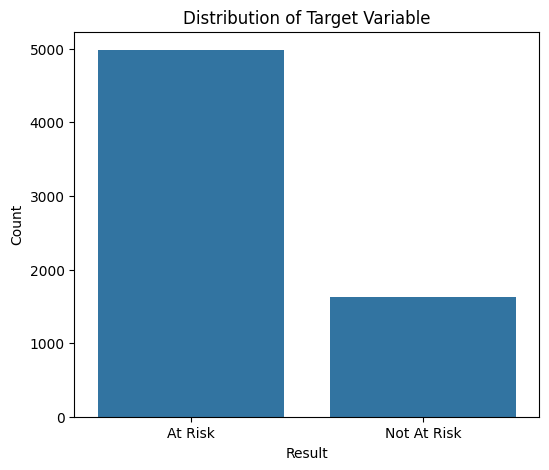

In [32]:
# Result distribution
plt.figure(figsize=(6, 5))
sns.countplot(x="Result", data=df)

plt.title("Distribution of Target Variable")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

Target variable is moderately imbalanced, with a high proportion of 'At Risk' students compared to 'Not At Risk' students. Class balancing techniques has to be applied during model training to handle this imbalance.

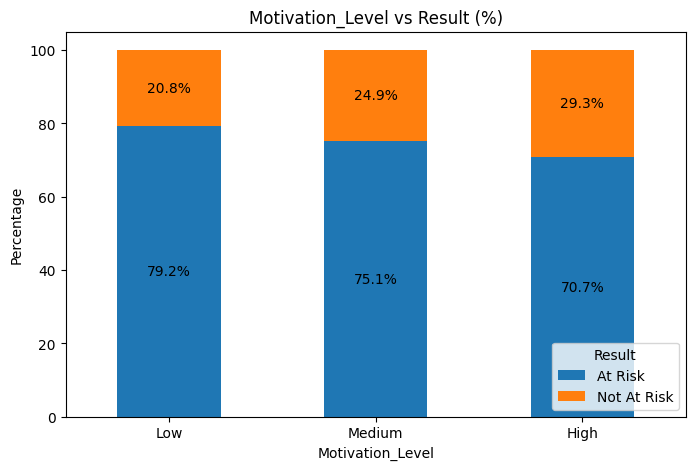

In [33]:
# Motivation_level vs Result
feature = "Motivation_Level"

result_percent = pd.crosstab( df[feature], df["Result"], normalize="index") * 100
ax = result_percent.plot(kind="bar", stacked=True, figsize=(8, 5))

labels = list(ordinal_mappings[feature].keys())
positions = range(len(labels))

plt.xticks(positions, labels, rotation=0)

plt.title(f"{feature} vs Result (%)")
plt.xlabel(feature)
plt.ylabel("Percentage")
plt.legend(title="Result",loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.show()


Students with higher motivation levels shows a lower proportion of 'At Risk' outcome, so motivation positively influences academic performance.

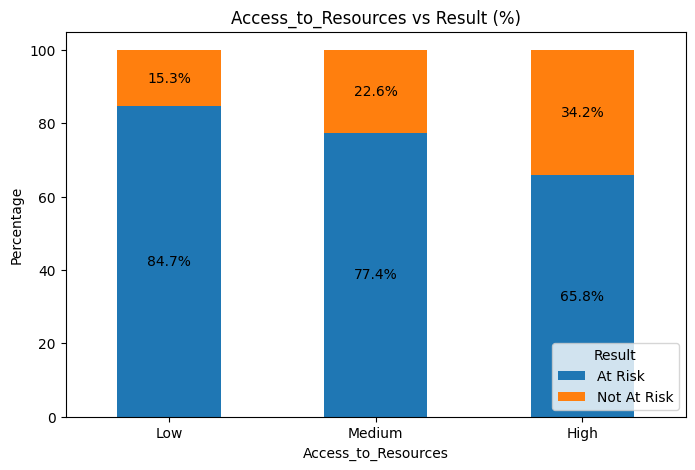

In [34]:
# Access_to_Resources vs Result
feature = "Access_to_Resources"

result_percent = pd.crosstab( df[feature], df["Result"], normalize="index") * 100
ax = result_percent.plot(kind="bar", stacked=True, figsize=(8, 5))

labels = list(ordinal_mappings[feature].keys())
positions = range(len(labels))

plt.xticks(positions, labels, rotation=0)

plt.title(f"{feature} vs Result (%)")
plt.xlabel(feature)
plt.ylabel("Percentage")
plt.legend(title="Result", loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")
    
plt.show()

Students with greater access to educational resources demonstrate a low proportion of 'At Risk' outcomes, showing the importance of resource availability in academic success..

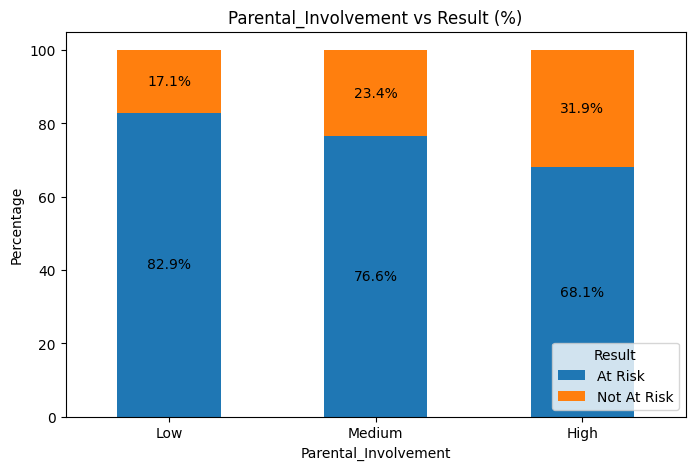

In [35]:
# Parental_involvement vs Result
feature = "Parental_Involvement"

result_percent = pd.crosstab( df[feature], df["Result"], normalize="index") * 100
ax = result_percent.plot(kind="bar", stacked=True, figsize=(8, 5))

labels = list(ordinal_mappings[feature].keys())
positions = range(len(labels))

plt.xticks(positions, labels, rotation=0)

plt.title(f"{feature} vs Result (%)")
plt.xlabel(feature)
plt.ylabel("Percentage")
plt.legend(title="Result", loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")
    
plt.show()


Higher parental involvement shows a lower percentage of 'At Risk'  students, suggesting family engagement contributes positively to academic outcomes.

### Model Building and Evaluation

In [36]:
# Target variable
df["Result"] = df["Result"].map({"At Risk": 1, "Not At Risk": 0})

In [37]:
X = df.drop(["Exam_Score", "Result"], axis=1)
y = df["Result"]

print(X.shape)
print(y.shape)

(6607, 19)
(6607,)


In [38]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape, X_test.shape)

(5285, 19) (1322, 19)


In [39]:
y_train.value_counts()

Result
1    3985
0    1300
Name: count, dtype: int64

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# Balancing the target variable
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

y_train_balanced.value_counts()

Result
1    3985
0    3985
Name: count, dtype: int64

In [42]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [43]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(" TRAINING PERFORMANCE :")
    print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

    print("\n TESTING PERFORMANCE :")
    print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))
    print(classification_report(y_test, y_test_pred))

    plot_confusion_matrix( y_test, y_test_pred, f"{type(model).__name__} Confusion Matrix" )

    return y_test_pred

#### Logistic Regression

In [44]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

 TRAINING PERFORMANCE :
Training Accuracy: 0.9606022584692597
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3985
           1       0.97      0.95      0.96      3985

    accuracy                           0.96      7970
   macro avg       0.96      0.96      0.96      7970
weighted avg       0.96      0.96      0.96      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.9576399394856279
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       325
           1       0.99      0.96      0.97       997

    accuracy                           0.96      1322
   macro avg       0.93      0.96      0.94      1322
weighted avg       0.96      0.96      0.96      1322



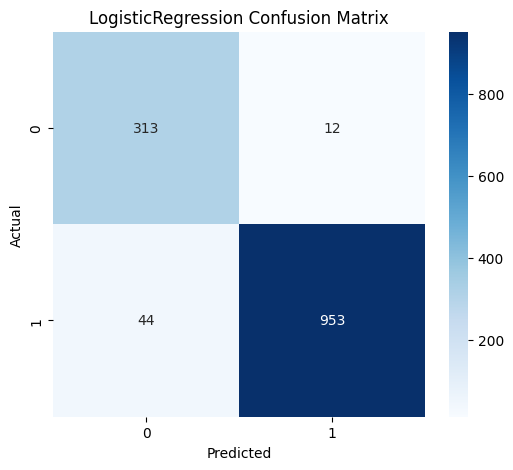

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [45]:
evaluate_model( lr_model, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

#### Decision Tree Classifier

In [46]:
dt_model = DecisionTreeClassifier(random_state=42)

 TRAINING PERFORMANCE :
Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3985
           1       1.00      1.00      1.00      3985

    accuracy                           1.00      7970
   macro avg       1.00      1.00      1.00      7970
weighted avg       1.00      1.00      1.00      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.8638426626323752
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       325
           1       0.92      0.90      0.91       997

    accuracy                           0.86      1322
   macro avg       0.81      0.83      0.82      1322
weighted avg       0.87      0.86      0.87      1322



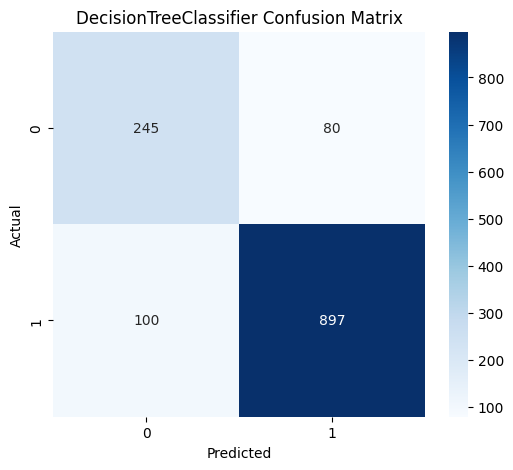

array([0, 0, 1, ..., 0, 1, 1], dtype=int64)

In [47]:
evaluate_model( dt_model, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

#### Random Forest Classifier

In [48]:
rf_model = RandomForestClassifier(random_state=42)

 TRAINING PERFORMANCE :
Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3985
           1       1.00      1.00      1.00      3985

    accuracy                           1.00      7970
   macro avg       1.00      1.00      1.00      7970
weighted avg       1.00      1.00      1.00      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.9311649016641452
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       325
           1       0.94      0.97      0.96       997

    accuracy                           0.93      1322
   macro avg       0.92      0.89      0.90      1322
weighted avg       0.93      0.93      0.93      1322



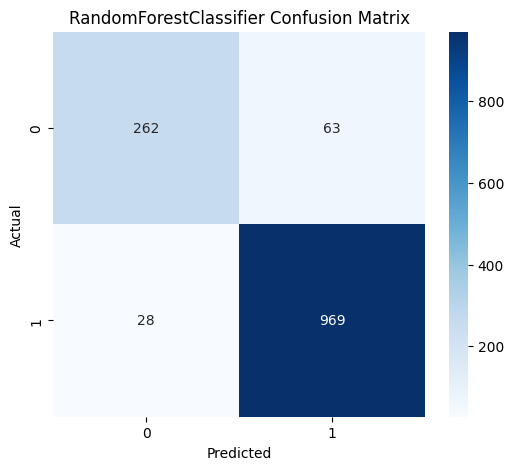

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [49]:
evaluate_model( rf_model, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

#### KNN Classifier

In [50]:
knn_model = KNeighborsClassifier()

 TRAINING PERFORMANCE :
Training Accuracy: 0.9129234629861982
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      3985
           1       0.99      0.84      0.91      3985

    accuracy                           0.91      7970
   macro avg       0.92      0.91      0.91      7970
weighted avg       0.92      0.91      0.91      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.7844175491679274
              precision    recall  f1-score   support

           0       0.54      0.84      0.66       325
           1       0.94      0.77      0.84       997

    accuracy                           0.78      1322
   macro avg       0.74      0.80      0.75      1322
weighted avg       0.84      0.78      0.80      1322



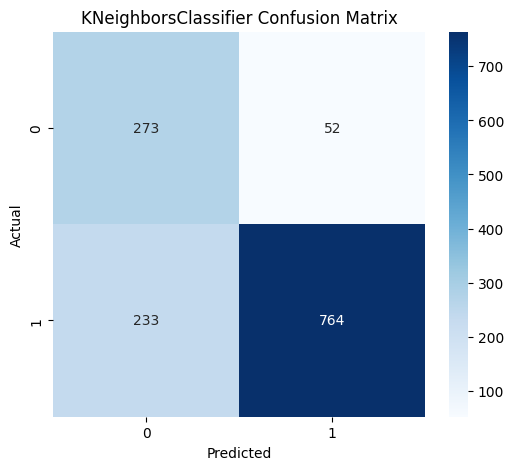

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [51]:
evaluate_model( knn_model, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

#### AdaBoost Classifier

In [52]:
ab_model = AdaBoostClassifier(random_state=42)

 TRAINING PERFORMANCE :
Training Accuracy: 0.9486825595984943
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3985
           1       0.96      0.93      0.95      3985

    accuracy                           0.95      7970
   macro avg       0.95      0.95      0.95      7970
weighted avg       0.95      0.95      0.95      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.9228441754916793
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       325
           1       0.97      0.93      0.95       997

    accuracy                           0.92      1322
   macro avg       0.89      0.91      0.90      1322
weighted avg       0.93      0.92      0.92      1322



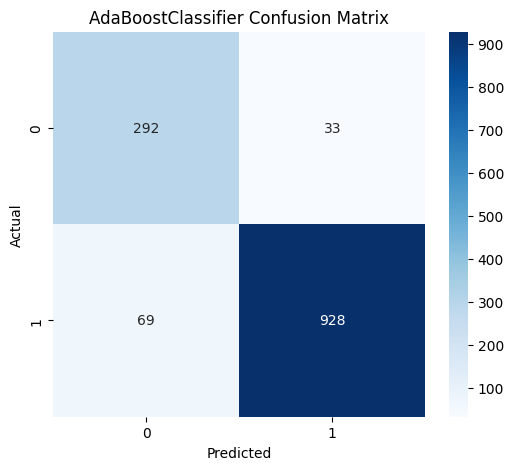

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [53]:
evaluate_model( ab_model, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

#### Gradient Boosting Classifier

In [54]:
gb_model = GradientBoostingClassifier(random_state=42)

 TRAINING PERFORMANCE :
Training Accuracy: 0.9702634880803012
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3985
           1       0.97      0.97      0.97      3985

    accuracy                           0.97      7970
   macro avg       0.97      0.97      0.97      7970
weighted avg       0.97      0.97      0.97      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.9508320726172466
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       325
           1       0.97      0.97      0.97       997

    accuracy                           0.95      1322
   macro avg       0.93      0.93      0.93      1322
weighted avg       0.95      0.95      0.95      1322



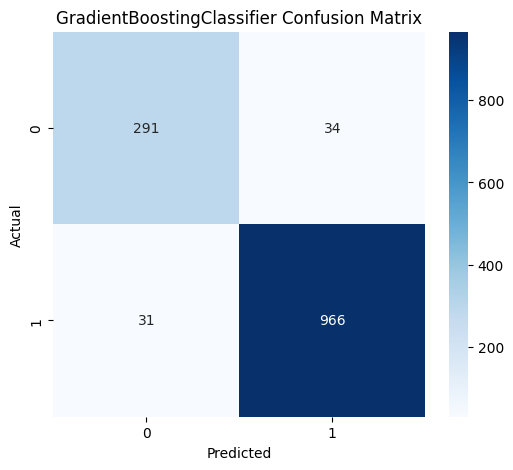

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [55]:
evaluate_model( gb_model, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

Choosing the Top 3 performing models (Logistic Regression, Random Forest, and Gradient Boosting) for hyperparameter tuning to further optimize predictive performance.

### Hyperparameter Tuning

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

#### Logistic Regression

In [61]:
param_grid_lr = { "penalty": ["l1", "l2"], "C": [0.001, 0.01, 0.1, 1, 10, 100], "solver": ["liblinear", "saga"] }

grid_lr = GridSearchCV( LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, scoring="accuracy", cv=5, n_jobs=-1, verbose=2 )
grid_lr.fit(X_train_balanced, y_train_balanced)

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross Validation Score:", grid_lr.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best Cross Validation Score: 0.9583437892095358


 TRAINING PERFORMANCE :
Training Accuracy: 0.9607277289836889
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3985
           1       0.97      0.95      0.96      3985

    accuracy                           0.96      7970
   macro avg       0.96      0.96      0.96      7970
weighted avg       0.96      0.96      0.96      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.9591527987897126
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       325
           1       0.99      0.96      0.97       997

    accuracy                           0.96      1322
   macro avg       0.93      0.96      0.95      1322
weighted avg       0.96      0.96      0.96      1322



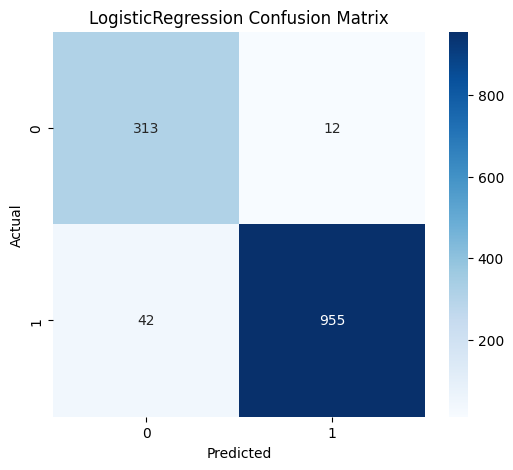

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [62]:
best_lr = grid_lr.best_estimator_
evaluate_model( best_lr, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

#### Random Forest Classifier

In [63]:
param_dist_rf = { "n_estimators": randint(50, 200), "max_depth": randint(5, 20), "min_samples_split": randint(2, 10),
                 "min_samples_leaf": randint(1, 5), "max_features": ["sqrt", "log2"],"criterion": ["gini", "entropy"] }

random_rf = RandomizedSearchCV( RandomForestClassifier(random_state=42), param_distributions=param_dist_rf, n_iter=20, cv=5, scoring="accuracy",
                               random_state=42, n_jobs=-1 )
random_rf.fit(X_train_balanced, y_train_balanced)

print("Best Parameters:", random_rf.best_params_)
print("Best Cross Validation Score:", random_rf.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 17, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 108}
Best Cross Validation Score: 0.9491844416562107


 TRAINING PERFORMANCE :
Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3985
           1       1.00      1.00      1.00      3985

    accuracy                           1.00      7970
   macro avg       1.00      1.00      1.00      7970
weighted avg       1.00      1.00      1.00      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.9387291981845688
              precision    recall  f1-score   support

           0       0.91      0.83      0.87       325
           1       0.95      0.97      0.96       997

    accuracy                           0.94      1322
   macro avg       0.93      0.90      0.91      1322
weighted avg       0.94      0.94      0.94      1322



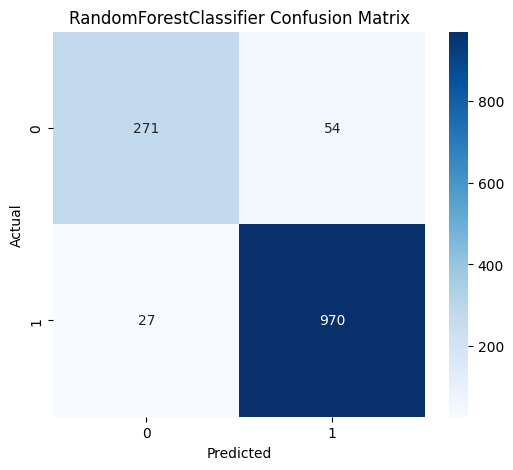

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [64]:
best_rf = random_rf.best_estimator_
evaluate_model( best_rf, X_train_balanced, X_test_scaled, y_train_balanced, y_test )

#### Gradient Boosting Classifier

In [57]:
param_grid_gb = {"n_estimators": [50, 100, 150, 200, 250], "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2], "max_depth": [2, 3, 4] }

grid_gb = GridSearchCV( GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring="accuracy",n_jobs=-1, verbose=2)

grid_gb.fit(X_train_balanced, y_train_balanced)

print("Best Parameters:", grid_gb.best_params_)
print("Best Cross Validation Score:", grid_gb.best_score_)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 250}
Best Cross Validation Score: 0.9623588456712673


 TRAINING PERFORMANCE :
Training Accuracy: 0.9868255959849436
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3985
           1       0.98      0.99      0.99      3985

    accuracy                           0.99      7970
   macro avg       0.99      0.99      0.99      7970
weighted avg       0.99      0.99      0.99      7970


 TESTING PERFORMANCE :
Testing Accuracy: 0.9667170953101362
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       325
           1       0.97      0.98      0.98       997

    accuracy                           0.97      1322
   macro avg       0.96      0.95      0.95      1322
weighted avg       0.97      0.97      0.97      1322



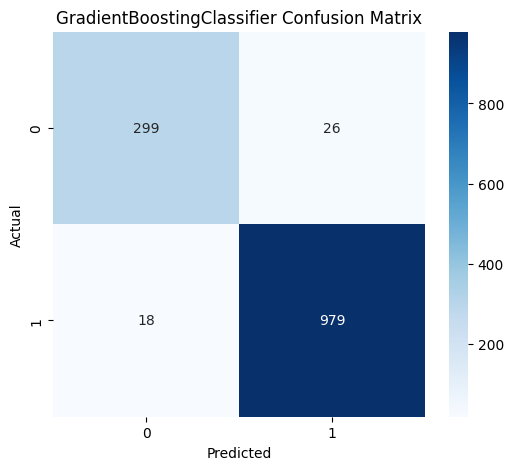

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [58]:
best_gb = grid_gb.best_estimator_
evaluate_model(best_gb,X_train_balanced,X_test_scaled,y_train_balanced,y_test)

In [59]:
from sklearn.metrics import roc_curve, auc

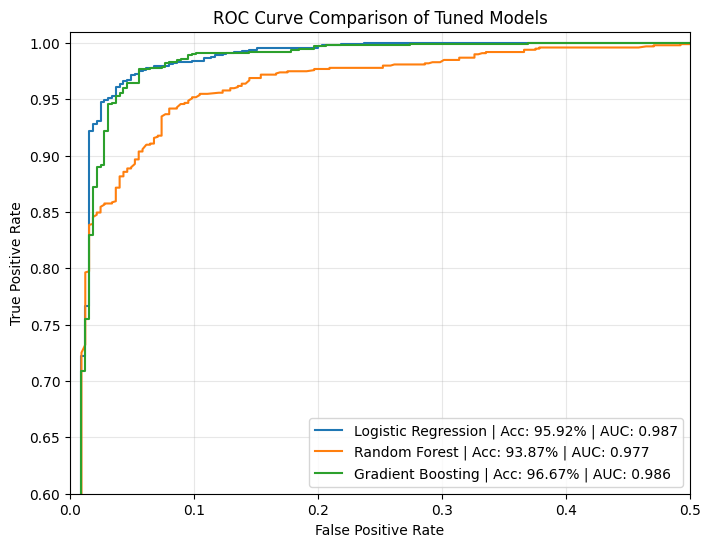

In [65]:
# Probabilities 
lr_probs = best_lr.predict_proba(X_test_scaled)[:, 1]
rf_probs = best_rf.predict_proba(X_test_scaled)[:, 1]
gb_probs = best_gb.predict_proba(X_test_scaled)[:, 1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

# AUC scores
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr,label=f"Logistic Regression | Acc: 95.92% | AUC: {lr_auc:.3f}")

plt.plot(rf_fpr, rf_tpr,label=f"Random Forest | Acc: 93.87% | AUC: {rf_auc:.3f}")

plt.plot(gb_fpr, gb_tpr,label=f"Gradient Boosting | Acc: 96.67% | AUC: {gb_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlim(0, 0.5)
plt.ylim(0.6, 1.01)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



#### After hyperparameter tuning, Gradient Boosting outperformed all other models with a testing accuracy of 96.67% and was selected as the final model for academic risk prediction.

### Model Interpretability using SHAP Analysis

In [66]:
import shap

In [67]:
explainer = shap.TreeExplainer(best_gb)

In [68]:
shap_values = explainer.shap_values(X_test_scaled)

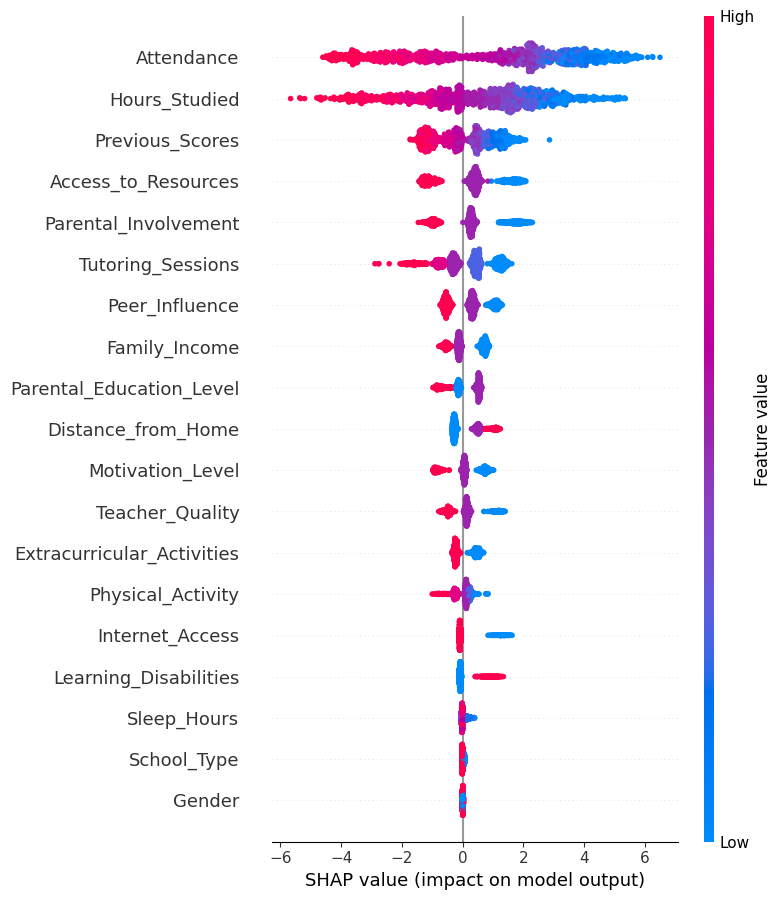

In [69]:
#Beeswarm plot
shap.summary_plot( shap_values, X_test_scaled, feature_names=X.columns )

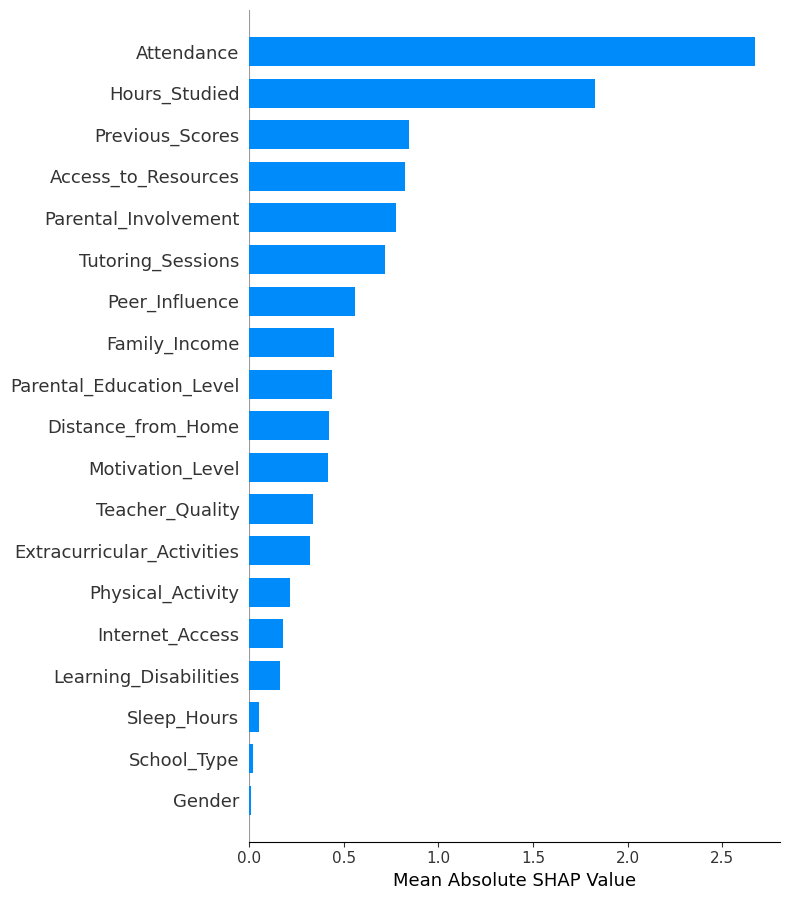

In [70]:
shap.summary_plot( shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar", show=False)

plt.xlabel("Mean Absolute SHAP Value")
plt.show()

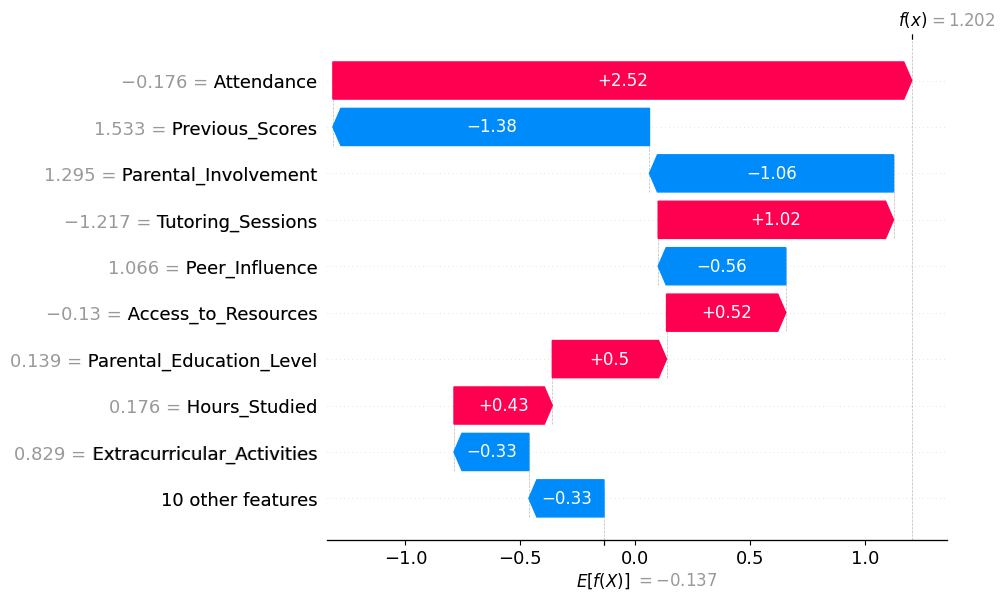

In [71]:
# Local SHAP explanation for a single student prediction
sample_index = 0

shap.waterfall_plot( shap.Explanation( values=shap_values[sample_index], base_values=explainer.expected_value,
                                      data=X_test_scaled[sample_index], feature_names=X.columns ))

The SHAP waterfall plot provides a local explanation for one student prediction by showing the contribution of each feature to the final model output. This helps in understanding which factors had the strongest positive or negative impact on the prediction.

In [72]:
sample_index = 0

prediction = best_gb.predict(X_test_scaled[sample_index].reshape(1, -1))
prediction_proba = best_gb.predict_proba( X_test_scaled[sample_index].reshape(1, -1))

print("Predicted Class:", prediction[0])

if prediction[0] == 1:
    print("Prediction Result: At Risk")
else:
    print("Prediction Result: Not At Risk")

print("Prediction Probabilities:", prediction_proba)

Predicted Class: 1
Prediction Result: At Risk
Prediction Probabilities: [[0.23107161 0.76892839]]


The above prediction corresponds to the same student instance used in the SHAP waterfall plot. This demonstrates how the model predicted the student's academic risk category and how individual feature contributions influenced that prediction.

### Model Saving for Deployment

In [73]:
import joblib

In [74]:
joblib.dump(best_gb, "student_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(ordinal_mappings, "ordinal_mappings.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']